# Calculate VIX shocks

This notebook loads `C:/Python/CSUREMM/data_primitive/vix.csv`, constructs VIX shock measures, and writes the outputs to the same output directory used by the S&P 500 workflow.

The notebook is designed to be run after the S&P 500 workflow directory structure exists. If your S&P 500 workflow uses a different output folder, edit `OUTPUT_DIR` in the configuration cell.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
INPUT_PATH = Path(r"C:/Python/CSUREMM/data_primitive/vix.csv")

# Use the same output directory as the S&P 500 workflow.
# Edit this line if your S&P 500 workflow uses a different folder.
OUTPUT_DIR = Path(r"C:/Python/CSUREMM/shock_detection/vix")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_PATH)
print("Output directory:", OUTPUT_DIR)

Input: C:\Python\CSUREMM\data_primitive\vix.csv
Output directory: C:\Python\CSUREMM\shock_detection\vix


## Load and standardize the VIX series

The code below accepts common date/value column names. It renames the date column to `date` and the VIX level column to `vix`.

In [3]:
def load_vix(input_path: Path) -> pd.DataFrame:
    df = pd.read_csv(input_path)

    # Detect date column.
    date_candidates = [
        "date", "Date", "DATE", "time", "Time", "TIME", "observation_date"
    ]
    date_col = next((c for c in date_candidates if c in df.columns), None)
    if date_col is None:
        date_col = df.columns[0]

    # Detect VIX value column.
    value_candidates = [
        "vix", "VIX", "close", "Close", "CLOSE", "value", "Value", "VALUE", "Adj Close", "Adj_Close"
    ]
    value_col = next((c for c in value_candidates if c in df.columns and c != date_col), None)
    if value_col is None:
        non_date_cols = [c for c in df.columns if c != date_col]
        if len(non_date_cols) != 1:
            raise ValueError(
                "Could not infer the VIX value column. "
                f"Columns found: {list(df.columns)}. Rename the VIX column to 'vix'."
            )
        value_col = non_date_cols[0]

    out = (
        df[[date_col, value_col]]
        .rename(columns={date_col: "date", value_col: "vix"})
        .copy()
    )
    out["date"] = pd.to_datetime(out["date"])
    out["vix"] = pd.to_numeric(out["vix"], errors="coerce")
    out = (
        out
        .dropna(subset=["date", "vix"])
        .sort_values("date")
        .drop_duplicates("date", keep="last")
        .reset_index(drop=True)
    )
    return out

vix = load_vix(INPUT_PATH)
vix.head(), vix.tail(), vix.shape

(        date        vix
 0 2022-01-03  16.600000
 1 2022-01-04  16.910000
 2 2022-01-05  19.730000
 3 2022-01-06  19.610001
 4 2022-01-07  18.760000,
            date        vix
 1101 2026-05-25  16.590000
 1102 2026-05-26  17.010000
 1103 2026-05-27  16.290001
 1104 2026-05-28  15.740000
 1105 2026-05-29  15.320000,
 (1106, 2))

## Compute VIX shocks

Definitions used here:

- `vix_change`: daily first difference in VIX level.
- `vix_pct_change`: daily percent change in VIX level.
- `vix_log_change`: daily log change in VIX level.
- `vix_change_z`: expanding-standardized daily VIX change, using only information available up to that date.
- `vix_shock_pos_1sd`: positive shock indicator where `vix_change_z >= 1`.
- `vix_shock_pos_2sd`: large positive shock indicator where `vix_change_z >= 2`.
- `vix_shock_neg_1sd`: negative shock indicator where `vix_change_z <= -1`.
- `vix_shock_abs_2sd`: large absolute shock indicator where `abs(vix_change_z) >= 2`.

In [4]:
def calculate_vix_shocks(df: pd.DataFrame, min_periods: int = 60) -> pd.DataFrame:
    out = df.copy()

    out["vix_change"] = out["vix"].diff()
    out["vix_pct_change"] = out["vix"].pct_change()
    out["vix_log_change"] = np.log(out["vix"]).diff()

    # Expanding mean/std shifted by one day to avoid look-ahead bias.
    expanding_mean = out["vix_change"].expanding(min_periods=min_periods).mean().shift(1)
    expanding_std = out["vix_change"].expanding(min_periods=min_periods).std(ddof=1).shift(1)

    out["vix_change_z"] = (out["vix_change"] - expanding_mean) / expanding_std

    out["vix_shock_pos_1sd"] = (out["vix_change_z"] >= 1).astype("Int64")
    out["vix_shock_pos_2sd"] = (out["vix_change_z"] >= 2).astype("Int64")
    out["vix_shock_neg_1sd"] = (out["vix_change_z"] <= -1).astype("Int64")
    out["vix_shock_abs_2sd"] = (out["vix_change_z"].abs() >= 2).astype("Int64")

    return out

vix_shocks = calculate_vix_shocks(vix, min_periods=60)
vix_shocks.head(70).tail(10)

,date,vix,vix_change,vix_pct_change,vix_log_change,vix_change_z,vix_shock_pos_1sd,vix_shock_pos_2sd,vix_shock_neg_1sd,vix_shock_abs_2sd
60,2022-03-30,19.330000,0.430000,0.022751,0.022496,NaN,0,0,0,0
61,2022-03-31,20.559999,1.230000,0.063632,0.061689,0.587977,0,0,0,0
62,2022-04-01,19.629999,-0.930000,-0.045233,-0.046288,-0.496609,0,0,0,0
63,2022-04-04,18.570000,-1.059999,-0.053999,-0.055512,-0.556956,0,0,0,0
64,2022-04-05,21.030001,2.460001,0.132472,0.124403,1.226780,1,0,0,0
65,2022-04-06,22.100000,1.070000,0.050880,0.049628,0.503585,0,0,0,0
66,2022-04-07,21.549999,-0.550001,-0.024887,-0.025202,-0.321223,0,0,0,0
67,2022-04-08,21.160000,-0.389999,-0.018097,-0.018263,-0.237011,0,0,0,0
68,2022-04-11,24.370001,3.210001,0.151701,0.141240,1.613041,1,0,0,0
69,2022-04-12,24.260000,-0.110001,-0.004514,-0.004524,-0.113815,0,0,0,0


## Save outputs

The notebook writes a full shock dataset and a compact event-only file to `OUTPUT_DIR`.

In [5]:
full_output_path = OUTPUT_DIR / "vix_shocks.csv"
event_output_path = OUTPUT_DIR / "vix_shock_events.csv"
summary_output_path = OUTPUT_DIR / "vix_shock_summary.csv"

vix_shocks.to_csv(full_output_path, index=False)

vix_events = vix_shocks.loc[
    vix_shocks[[
        "vix_shock_pos_1sd",
        "vix_shock_pos_2sd",
        "vix_shock_neg_1sd",
        "vix_shock_abs_2sd",
    ]].fillna(0).any(axis=1)
].copy()
vix_events.to_csv(event_output_path, index=False)

summary = pd.DataFrame({
    "metric": [
        "n_observations",
        "start_date",
        "end_date",
        "n_pos_1sd_shocks",
        "n_pos_2sd_shocks",
        "n_neg_1sd_shocks",
        "n_abs_2sd_shocks",
    ],
    "value": [
        len(vix_shocks),
        vix_shocks["date"].min(),
        vix_shocks["date"].max(),
        int(vix_shocks["vix_shock_pos_1sd"].sum(skipna=True)),
        int(vix_shocks["vix_shock_pos_2sd"].sum(skipna=True)),
        int(vix_shocks["vix_shock_neg_1sd"].sum(skipna=True)),
        int(vix_shocks["vix_shock_abs_2sd"].sum(skipna=True)),
    ]
})
summary.to_csv(summary_output_path, index=False)

print("Saved:")
print(full_output_path)
print(event_output_path)
print(summary_output_path)
summary

Saved:
C:\Python\CSUREMM\shock_detection\vix\vix_shocks.csv
C:\Python\CSUREMM\shock_detection\vix\vix_shock_events.csv
C:\Python\CSUREMM\shock_detection\vix\vix_shock_summary.csv


,metric,value
0,n_observations,1106
1,start_date,2022-01-03 00:00:00
2,end_date,2026-05-29 00:00:00
3,n_pos_1sd_shocks,96
4,n_pos_2sd_shocks,25
5,n_neg_1sd_shocks,77
6,n_abs_2sd_shocks,38


## Optional: quick diagnostic plot

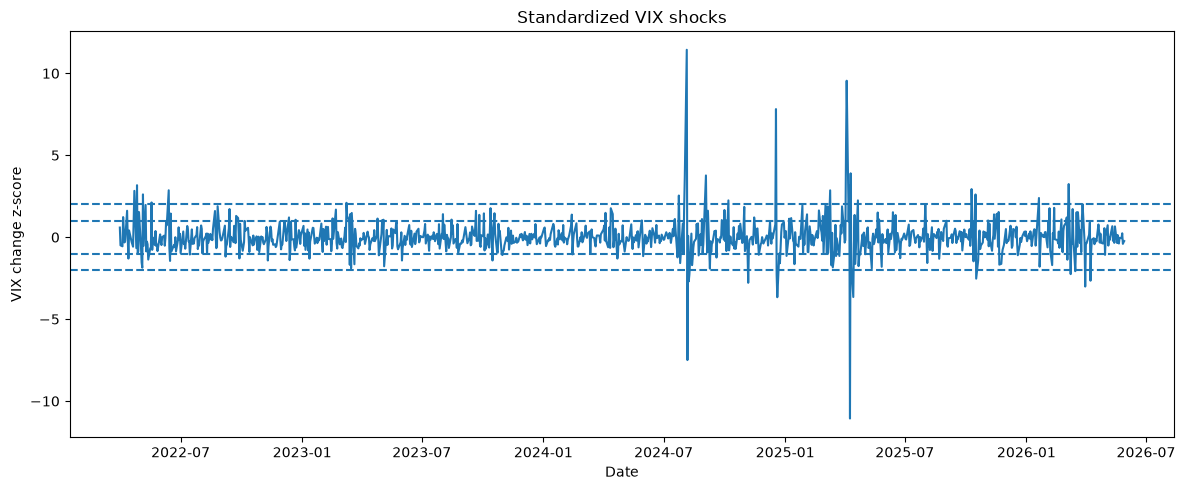

In [6]:
import matplotlib.pyplot as plt

plot_df = vix_shocks.dropna(subset=["vix_change_z"])

plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["vix_change_z"])
plt.axhline(2, linestyle="--")
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.title("Standardized VIX shocks")
plt.xlabel("Date")
plt.ylabel("VIX change z-score")
plt.tight_layout()
plt.show()